## Performance Analysis

# 1. YEARLY RETURNS

In [4]:
import pandas as pd
import sqlite3
conn = sqlite3.connect("../db/nifty100.db")

prices = pd.read_sql("SELECT * FROM stock_prices", conn)

prices.columns = [
	"record_id",
	"company_name",
	"date",
	"open_price",
	"high_price",
	"low_price",
	"close_price",
	"volume",
	"adjusted_close",
]

prices["company_name"] = prices["company_name"].astype(str).str.strip()
prices["date"] = pd.to_datetime(prices["date"], errors="coerce")
prices["close_price"] = pd.to_numeric(prices["close_price"], errors="coerce")

prices = prices.dropna(subset=["date", "close_price"])

print(prices.head())

   record_id company_name       date  open_price  high_price  low_price  \
0          2          ABB 2020-02-01     2177.03     2192.92    1931.08   
1          3          ABB 2020-03-01     2221.26     2440.28    1995.23   
2          4          ABB 2020-04-01     1932.02     2027.44    1740.12   
3          5          ABB 2020-05-01     2089.00     2290.96    1878.23   
4          6          ABB 2020-06-01     2114.21     2359.95    2101.69   

   close_price    volume  adjusted_close  
0      2165.21   1668316         2165.21  
1      2198.78  20578107         2198.78  
2      1958.56  14558597         1958.56  
3      2085.72  44638694         2085.72  
4      2147.71  15968373         2147.71  


In [5]:
prices = prices.sort_values(["company_name", "date"])
prices["return"] = prices.groupby("company_name")["close_price"].pct_change()
print(prices[["company_name", "date", "return"]].head())

  company_name       date    return
0          ABB 2020-02-01       NaN
1          ABB 2020-03-01  0.015504
2          ABB 2020-04-01 -0.109251
3          ABB 2020-05-01  0.064925
4          ABB 2020-06-01  0.029721


In [6]:
avg_returns = prices.groupby("company_name")["return"].mean().sort_values(ascending=False)

print(avg_returns.head(10))

company_name
INDIGO        0.024863
JIOFIN        0.022181
SBIN          0.021972
PNB           0.020863
ADANIPOWER    0.020674
ITC           0.019851
TATASTEEL     0.019702
INDUSINDBK    0.019279
MARUTI        0.019194
AMBUJACEM     0.018379
Name: return, dtype: float64


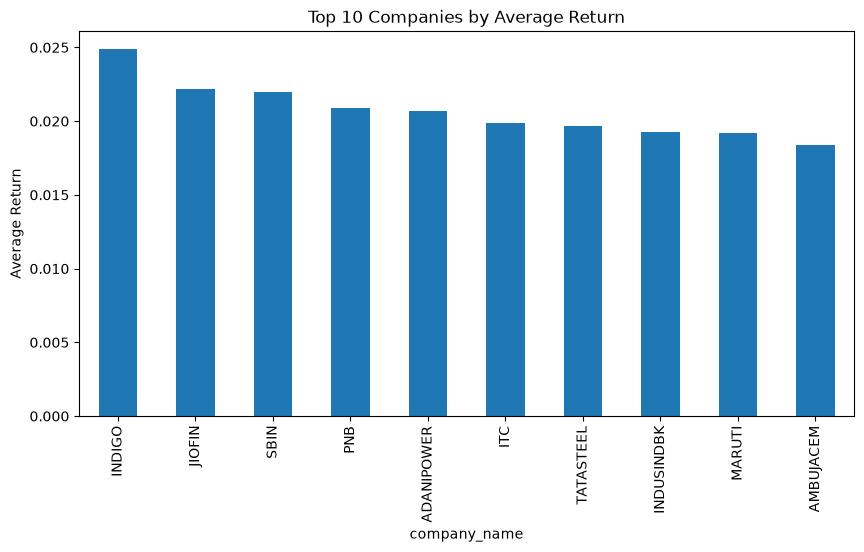

In [7]:
import matplotlib.pyplot as plt

top = avg_returns.head(10)

plt.figure(figsize=(10,5))
top.plot(kind="bar")
plt.title("Top 10 Companies by Average Return")
plt.ylabel("Average Return")
plt.show()

# 2.TOTAL RETURN

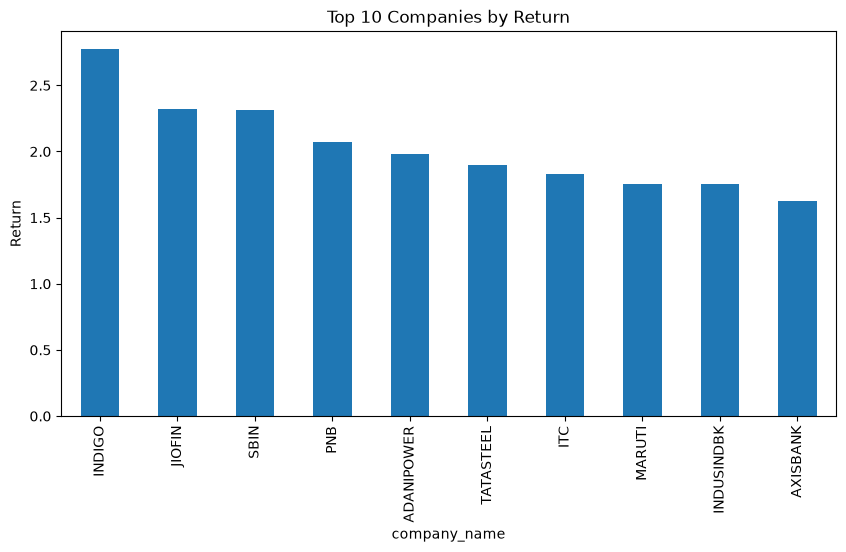

In [8]:
total_return = prices.groupby("company_name")["close_price"].agg(
    lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0]
)

top_returns = total_return.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_returns.plot(kind="bar")

plt.title("Top 10 Companies by Return")
plt.ylabel("Return")

plt.show()

# 3 VOLATILITY

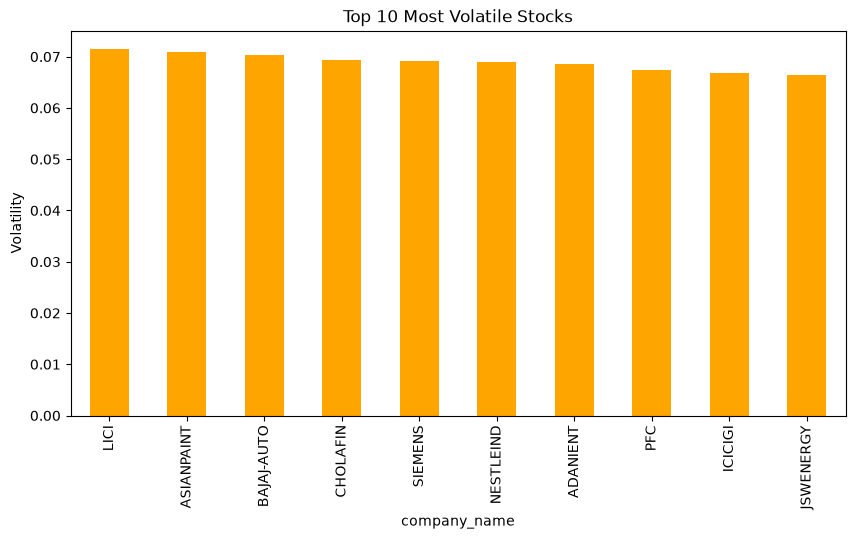

In [9]:
volatility = prices.groupby("company_name")["return"].std()
top_vol = volatility.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_vol.plot(kind="bar", color="orange")
plt.title("Top 10 Most Volatile Stocks")
plt.ylabel("Volatility")
plt.show()

# 4 BEST PERFORMING SECTOR

In [14]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../db/nifty100.db")
companies = pd.read_sql("SELECT * FROM companies", conn)
prices = pd.read_sql("SELECT * FROM stock_prices", conn)

sectors = pd.read_excel("../data/raw/sectors.xlsx", header=1)
companies.columns = companies.columns.str.strip().str.lower()
sectors.columns = sectors.columns.str.strip().str.lower()

companies = companies.rename(columns={"id": "company_id"})
sectors = sectors.rename(columns={"abb": "company_id"})

companies["company_id"] = companies["company_id"].astype(str).str.strip()
sectors["company_id"] = sectors["company_id"].astype(str).str.strip()

merged = companies.merge(sectors, on="company_id", how="left")

In [16]:
prices.columns = [
	"record_id",
	"company_name",
	"date",
	"open_price",
	"high_price",
	"low_price",
	"close_price",
	"volume",
	"adjusted_close",
]

prices["company_name"] = prices["company_name"].astype(str).str.strip()
prices["date"] = pd.to_datetime(prices["date"], errors="coerce")
prices["close_price"] = pd.to_numeric(prices["close_price"], errors="coerce")

prices = prices.dropna(subset=["date", "close_price"])

In [17]:
prices = prices.sort_values(["company_name", "date"])
prices["return"] = prices.groupby("company_name")["close_price"].pct_change()

In [19]:
perf = prices.merge(
    merged[["company_name", "industrials"]].rename(
        columns={"industrials": "broad_sector"}
    ),
    on="company_name",
    how="left"
)

Series([], Name: return, dtype: float64)


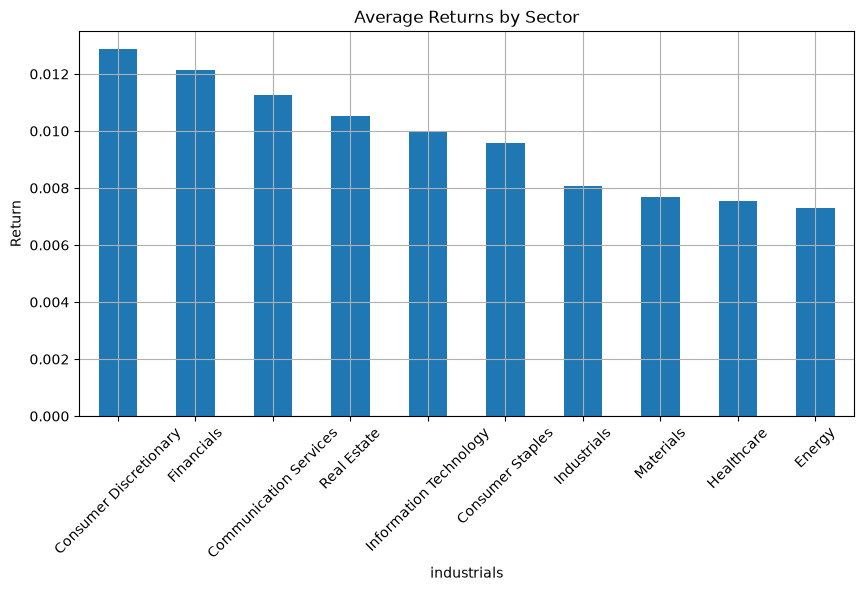

In [21]:
sector_perf = perf.groupby("broad_sector")["return"].mean().sort_values(ascending=False)
print(sector_perf)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sector_perf = (
    perf.drop(columns=["broad_sector"], errors="ignore")
    .merge(
        merged[["company_id", "industrials"]],
        left_on="company_name",
        right_on="company_id",
        how="left",
    )
    .groupby("industrials")["return"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

sector_perf.plot(kind="bar")
plt.title("Average Returns by Sector")
plt.ylabel("Return")
plt.xticks(rotation=45)
plt.grid()
plt.show()

 # 5. TOP PERFORMING COMPANIES

company_name
INDIGO        0.024863
JIOFIN        0.022181
SBIN          0.021972
PNB           0.020863
ADANIPOWER    0.020674
ITC           0.019851
TATASTEEL     0.019702
INDUSINDBK    0.019279
MARUTI        0.019194
AMBUJACEM     0.018379
Name: return, dtype: float64


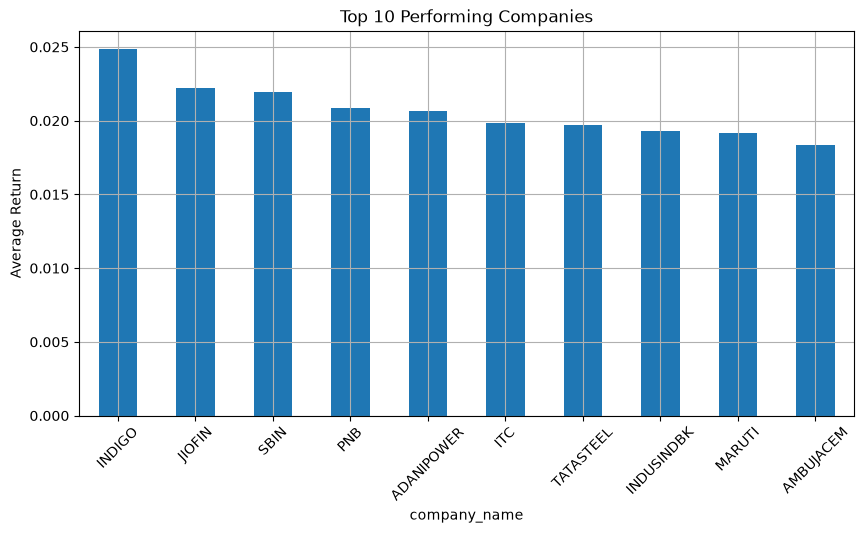

In [22]:
top_companies = (
    prices.groupby("company_name")["return"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_companies)

plt.figure(figsize=(10,5))
top_companies.plot(kind="bar")
plt.title("Top 10 Performing Companies")
plt.ylabel("Average Return")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 6. WORST PERFORMING COMPANIES

company_name
BRITANNIA    -0.009509
COALINDIA    -0.006771
APOLLOHOSP   -0.004799
RELIANCE     -0.004184
PIDILITIND   -0.003442
SIEMENS      -0.002831
ADANIENSOL   -0.002611
IOC          -0.000897
ATGL          0.000207
TORNTPHARM    0.000676
Name: return, dtype: float64


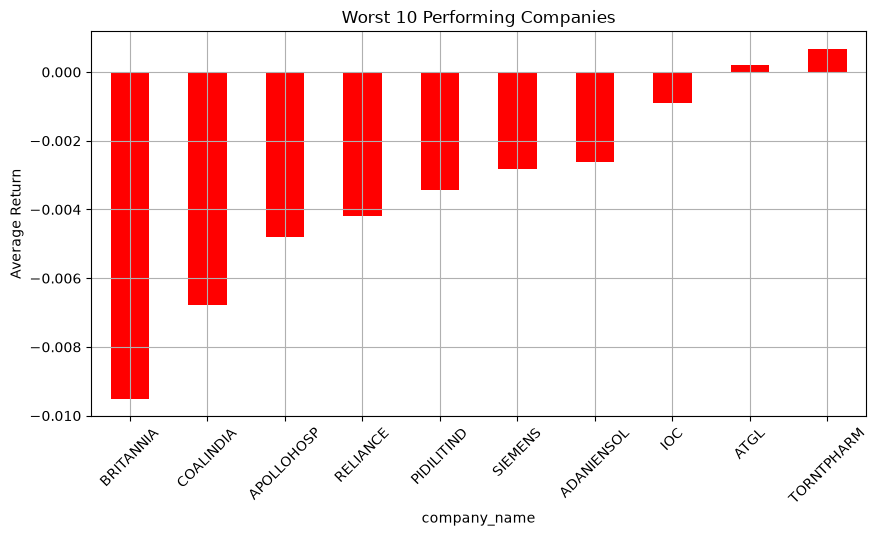

In [23]:
worst_companies = (
    prices.groupby("company_name")["return"]
    .mean()
    .sort_values(ascending=True)
    .head(10)
)

print(worst_companies)

plt.figure(figsize=(10,5))
worst_companies.plot(kind="bar", color="red")
plt.title("Worst 10 Performing Companies")
plt.ylabel("Average Return")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 7. VOLATILITY ANALYSIS

company_name
LICI          0.071523
ASIANPAINT    0.070950
BAJAJ-AUTO    0.070296
CHOLAFIN      0.069319
SIEMENS       0.069070
NESTLEIND     0.068991
ADANIENT      0.068558
PFC           0.067416
ICICIGI       0.066883
JSWENERGY     0.066452
Name: return, dtype: float64


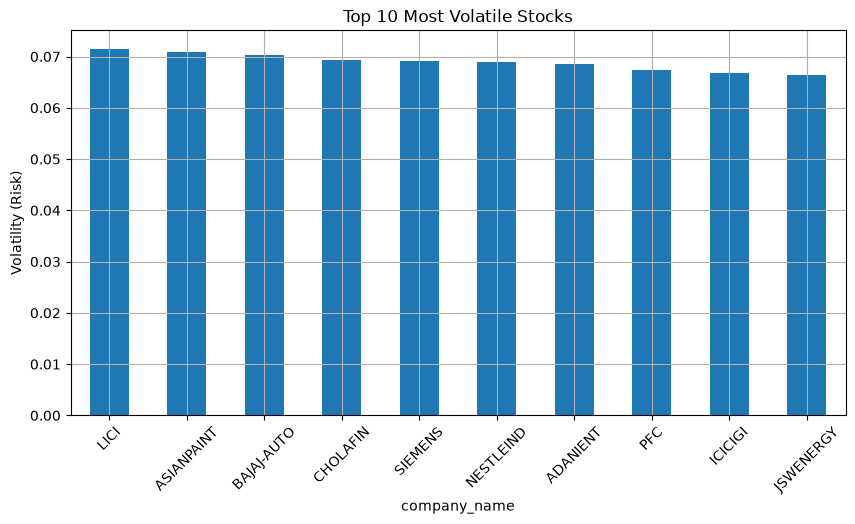

In [24]:
volatility = (
    prices.groupby("company_name")["return"]
    .std()
    .sort_values(ascending=False)
    .head(10)
)

print(volatility)

plt.figure(figsize=(10,5))
volatility.plot(kind="bar")
plt.title("Top 10 Most Volatile Stocks")
plt.ylabel("Volatility (Risk)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 8. RISK vs RETURN

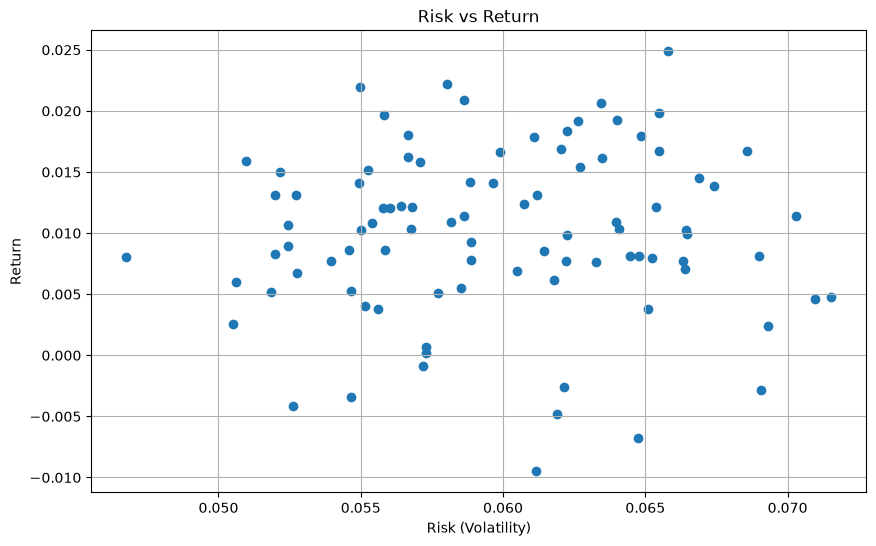

In [25]:
risk_return = prices.groupby("company_name")["return"].agg(["mean", "std"])

plt.figure(figsize=(10,6))
plt.scatter(risk_return["std"], risk_return["mean"])

plt.title("Risk vs Return")
plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")

plt.grid()
plt.show()

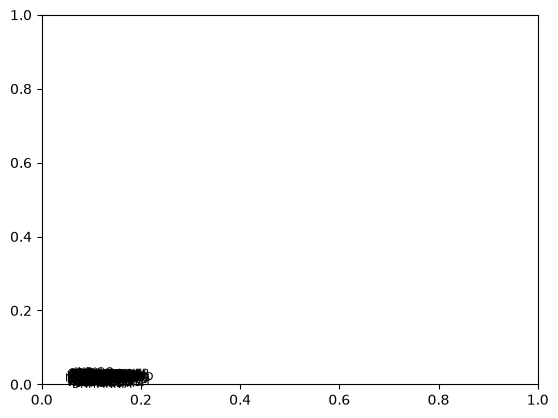

In [26]:
for i in risk_return.index:
    plt.text(risk_return.loc[i, "std"], risk_return.loc[i, "mean"], i, fontsize=8)

##  Performance Insights

- Some companies show consistently high returns, indicating strong growth.

- High volatility stocks carry higher risk but also potential high returns.

- Certain sectors outperform others in terms of average returns.

- Market capitalization is concentrated among a few large companies.

- Volume and price movements indicate investor activity and demand.

- Returns analysis helps identify best-performing stocks over time.